# SVM Classification

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
df = pd.read_csv("D:\\Data Sets\\default of credit card clients.csv", header = 1)
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [4]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [5]:
df.shape

(30000, 25)

In [6]:
df = df.drop("ID", axis=1)
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


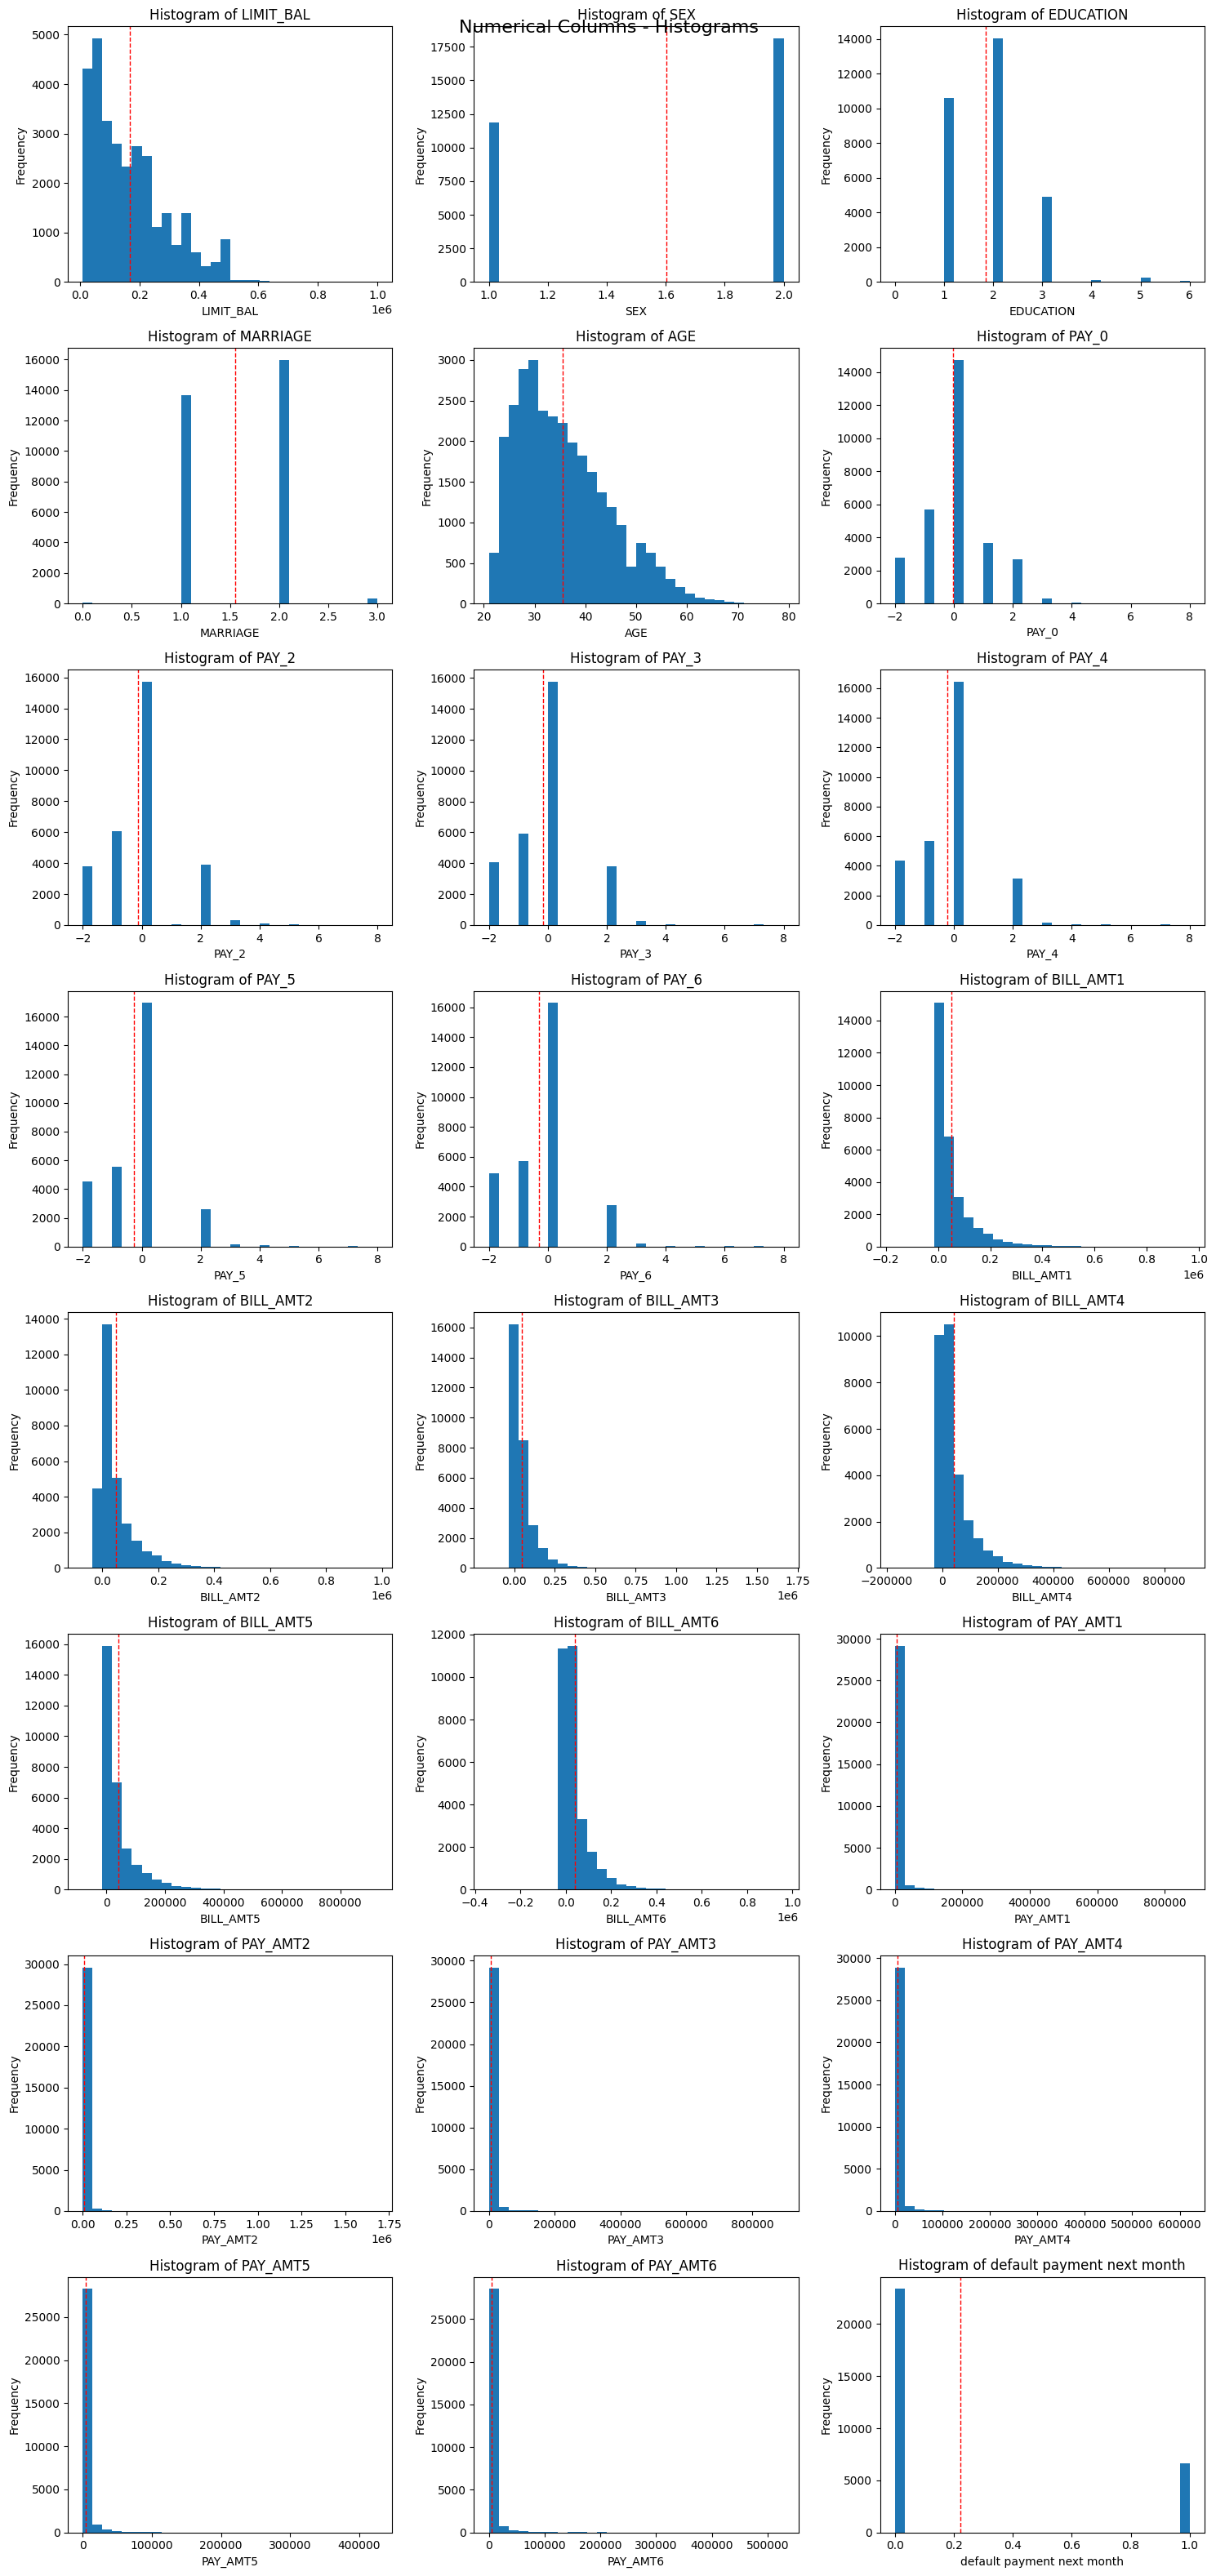

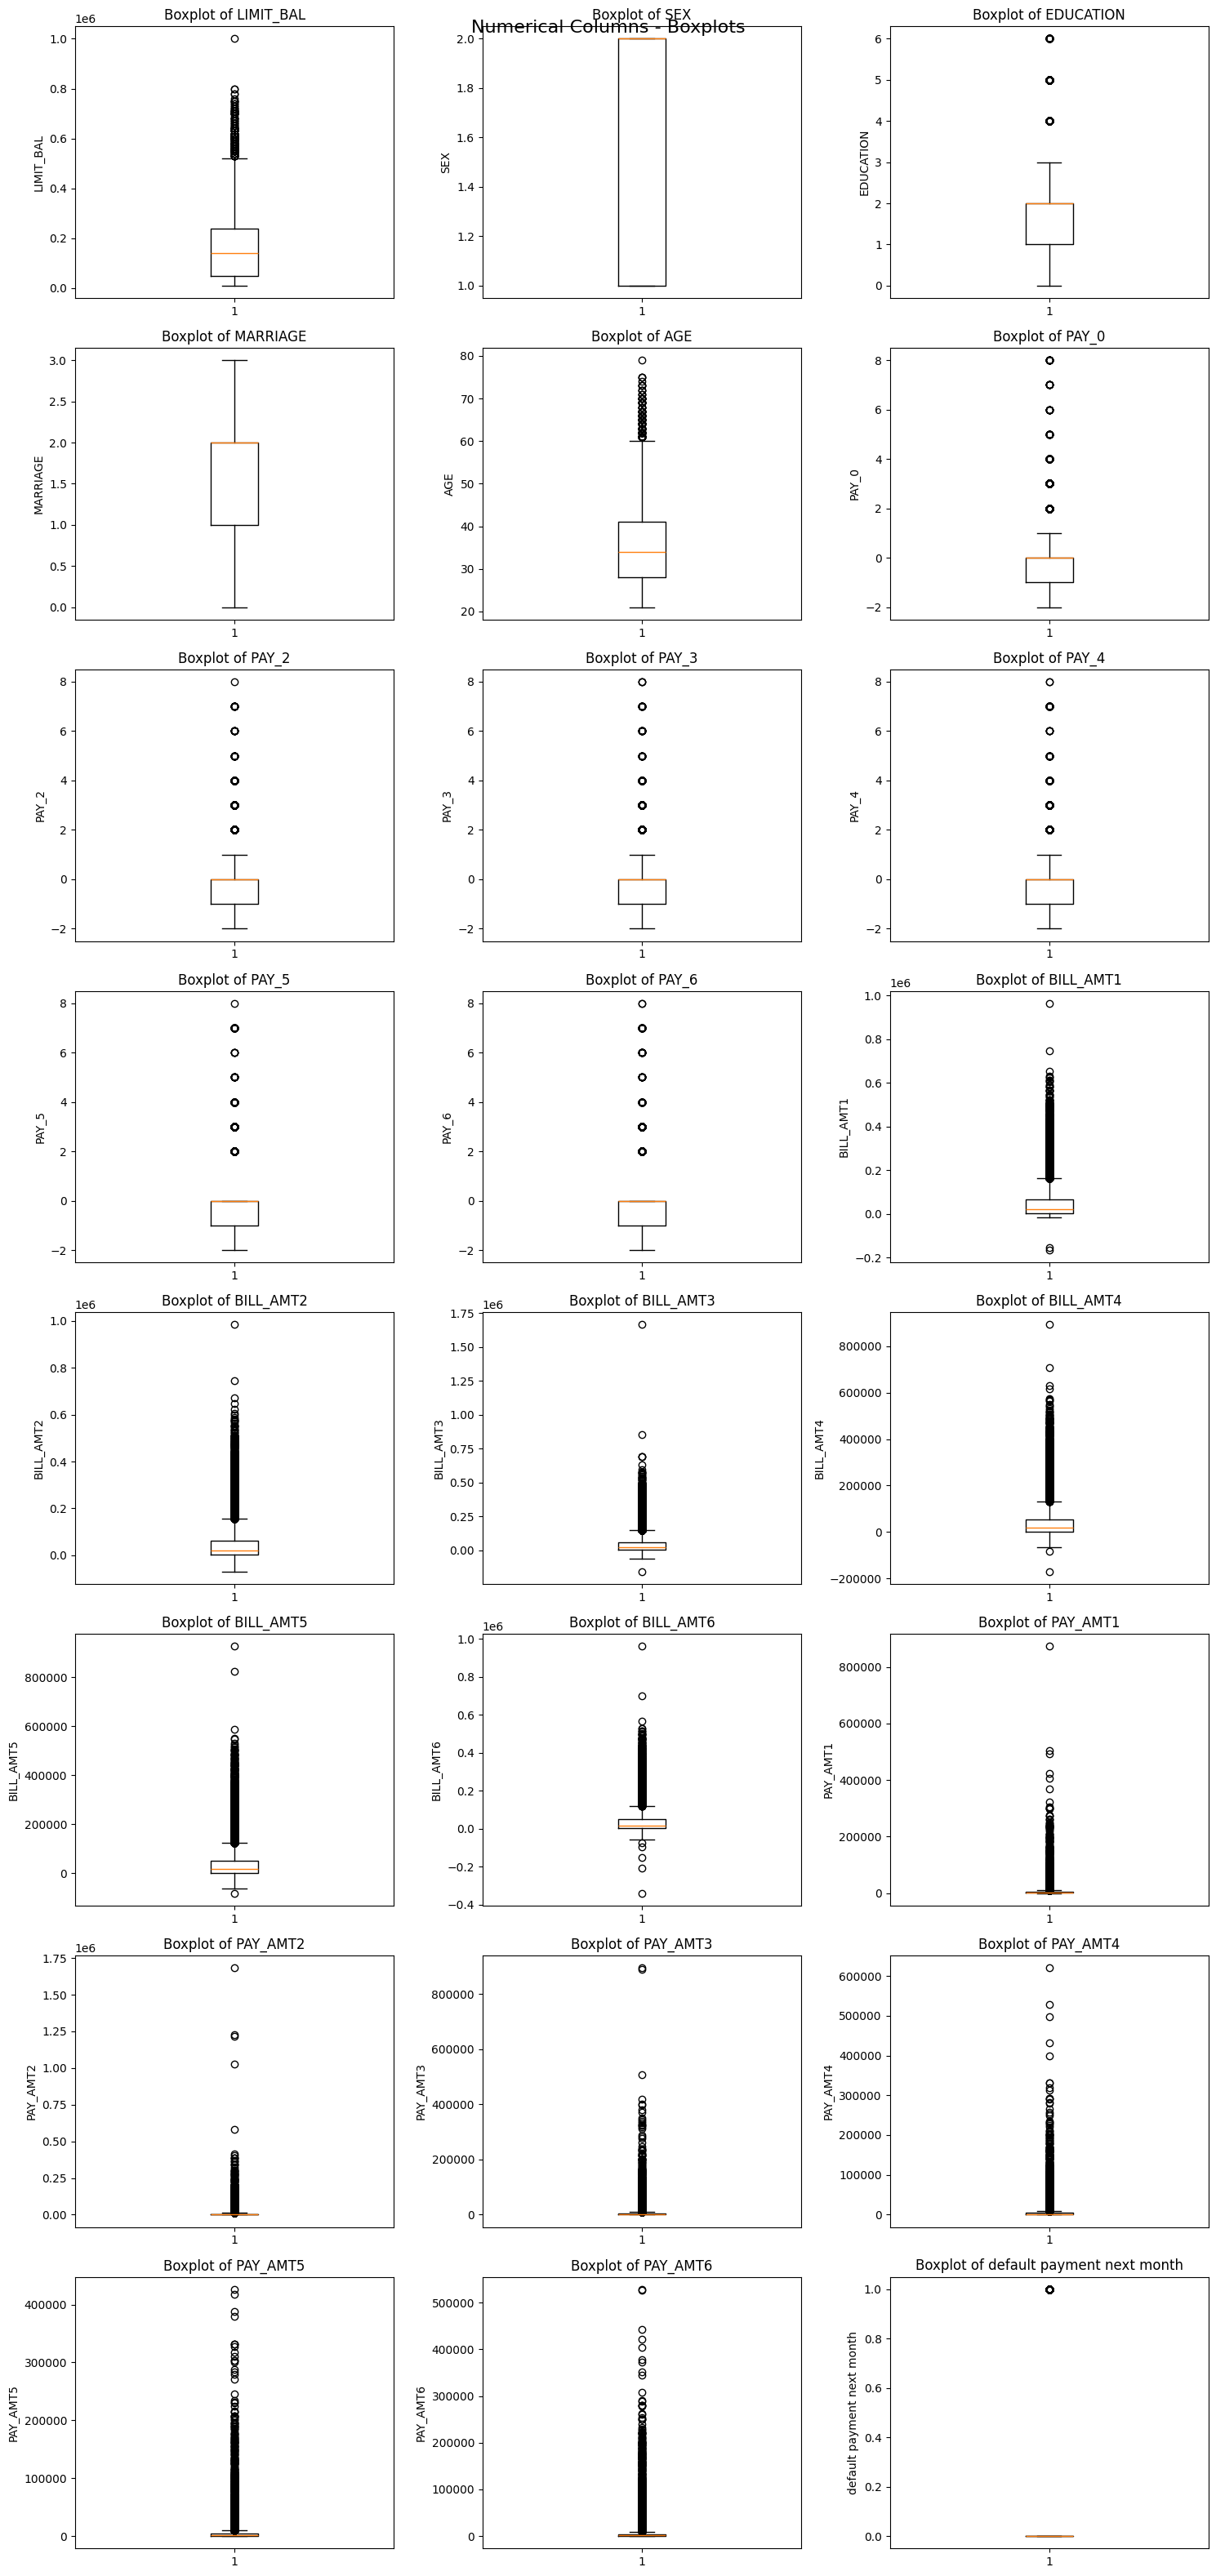

In [7]:
def eda_plots(df):
    numerical_cols = df.select_dtypes(include='number').columns

    if len(numerical_cols) > 0:
        n_cols = 3
        n_rows = math.ceil(len(numerical_cols) / n_cols)

        plt.figure(figsize=(5 * n_cols, 4 * n_rows))
        for i, col in enumerate(numerical_cols, 1):
            plt.subplot(n_rows, n_cols, i)
            mean = df[col].mean()
            plt.axvline(mean, color='r', linestyle='dashed', linewidth=1)
            plt.hist(df[col].dropna(), bins=30)
            plt.title(f'Histogram of {col}')
            plt.xlabel(col)
            plt.ylabel('Frequency')

        plt.suptitle('Numerical Columns - Histograms', fontsize=16)
        plt.tight_layout()
        plt.show()

    if len(numerical_cols) > 0:
        n_cols = 3
        n_rows = math.ceil(len(numerical_cols) / n_cols)

        plt.figure(figsize=(5 * n_cols, 4 * n_rows))
        for i, col in enumerate(numerical_cols, 1):
            plt.subplot(n_rows, n_cols, i)
            plt.boxplot(df[col].dropna())
            plt.title(f'Boxplot of {col}')
            plt.ylabel(col)

        plt.suptitle('Numerical Columns - Boxplots', fontsize=16)
        plt.tight_layout()
        plt.show()

eda_plots(df)

In [8]:
X = df.drop('default payment next month', axis=1)
y = df['default payment next month']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [9]:
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

In [10]:
l_svc = LinearSVC(random_state=42, max_iter=10000)
l_svc.fit(X_train_sc, y_train)
y_pred_lsvc = l_svc.predict(X_test_sc)

In [11]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

In [12]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)

In [13]:
results = {
    'Algorithm': ['SVC (Linear)', 'Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lsvc),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'F1-Score (Macro)': [
        f1_score(y_test, y_pred_lsvc, average='macro'),
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro')
    ]
}

comparison_df = pd.DataFrame(results)
display(comparison_df)

,Algorithm,Accuracy,F1-Score (Macro)
0,SVC (Linear),0.804333,0.58920
1,Logistic Regression,0.807667,0.62114
2,Random Forest,0.811667,0.67141


The comparison table shows that all four models perform similarly on this dataset. The linear SVC and logistic regression provide competitive accuracy, while the random forest slightly improves the macro F1-score, indicating better balance across classes. The tuned RBF SVC yields the highest accuracy but a marginally lower macro F1-score than the random forest, suggesting a small trade-off between overall accuracy and class-balanced performance. Overall, the improvements from tuning are modest, so model choice can prioritize interpretability or computational cost.

In [14]:
X_train_small, _, y_train_small, _ = train_test_split(X_train_sc, y_train, train_size=2000, random_state=42, stratify=y_train)

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001]
}

In [15]:
grid = GridSearchCV(SVC(kernel='rbf'), param_grid, refit=True, verbose=1, cv=3)
grid.fit(X_train_small, y_train_small)

grid.best_params_

Fitting 3 folds for each of 16 candidates, totalling 48 fits


{'C': 10, 'gamma': 0.01}

In [16]:
y_pred_tuned = grid.predict(X_test_sc)

In [17]:
tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned, average='macro')

print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.83      0.95      0.89      4673
           1       0.66      0.32      0.43      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.64      0.66      6000
weighted avg       0.79      0.81      0.79      6000



The table summarizes the test performance of four classifiers using Accuracy and Macro F1-Score. Random Forest has the highest Macro F1-Score, indicating better class-balanced performance, while the tuned RBF SVC slightly edges out others in Accuracy. Linear SVC and Logistic Regression are close in Accuracy but trail in Macro F1-Score, suggesting weaker balance across classes.

In [18]:
tuned_res = {
    'Algorithm': 'SVC (Tuned RBF)', 
    'Accuracy': accuracy_score(y_test, y_pred_tuned),
    'F1-Score (Macro)': f1_score(y_test, y_pred_tuned, average='macro')
}

tuned_res_df = pd.DataFrame([tuned_res])
comparison_df = pd.concat([comparison_df, tuned_res_df], ignore_index=True)


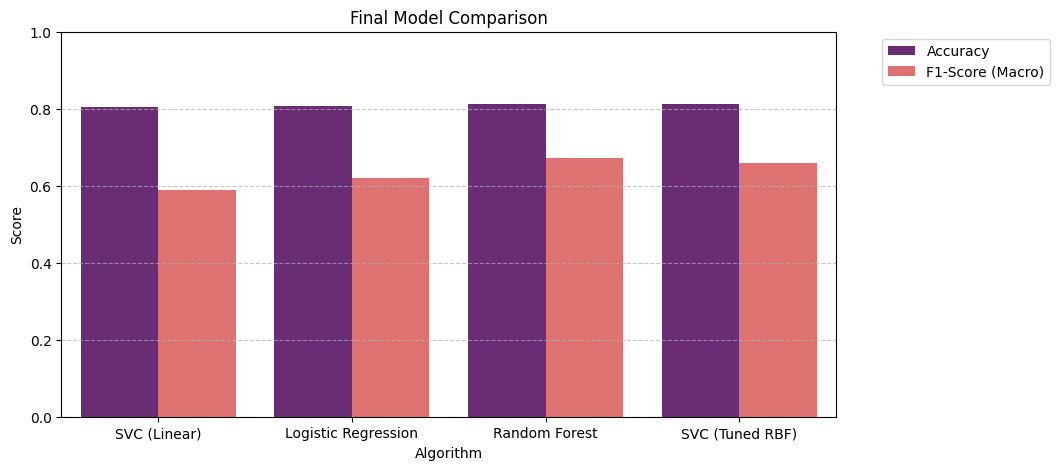

In [19]:
plt.figure(figsize=(10, 5))
melted_df = comparison_df.melt(id_vars='Algorithm', var_name='Metric', value_name='Score')

sns.barplot(data=melted_df, x='Algorithm', y='Score', hue='Metric', palette='magma')
plt.title('Final Model Comparison')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The bar chart compares the Accuracy and Macro F1-Score across the four models. The tuned RBF SVC slightly leads in Accuracy, while the Random Forest achieves the highest Macro F1-Score, indicating better class-balanced performance. Linear SVC and Logistic Regression perform similarly but trail in Macro F1-Score. Overall, differences are modest, suggesting comparable performance with a small trade-off between accuracy and balance.

## Conclusion

Overall, the models show comparable performance on the credit default dataset. The tuned RBF SVC achieves the highest accuracy, while Random Forest provides the best macro F1-score, indicating stronger class-balanced performance. Given the modest differences, model selection can prioritize interpretability (Logistic Regression/Linear SVC) or balance (Random Forest) depending on deployment goals.